# Phase 2 (Finetune)

---

1. Import Perangkat Tempur & Metrik Evaluasi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import rasterio
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.12.0+cpu
CUDA Available: False


2. Konfigurasi & Jalur "Otak" Phase 1

In [2]:
# Setup Jalur Folder
BASE_DIR = Path(".").resolve().parent
CSV_PATH = BASE_DIR / "data" / "processed" / "dataset_metadata_final.csv"
PATCHES_DIR = BASE_DIR / "data" / "processed" / "patches_jabar"
MODEL_DIR = BASE_DIR / "models"
PRETRAINED_WEIGHTS_PATH = MODEL_DIR / "pretrained_encoder_weights.pth"

# Hyperparameters Phase 2 (Ringan untuk CPU)
BATCH_SIZE = 32
EPOCHS = 10              # Klasifikasi biasanya lebih cepat konvergen dibanding Autoencoder
LEARNING_RATE = 5e-5     # Learning rate kecil agar tidak merusak fitur yang sudah dipelajari
NUM_CHANNELS = 6         # Sesuai karakteristik citra satelit kamu (6 Band)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Phase 2 running on: {DEVICE}")

🚀 Phase 2 running on: cpu


3. Custom Dataset Klasifikasi (Mendukung Slum & Non-Slum)

In [3]:
class SatelliteClassifierDataset(Dataset):
    def __init__(self, csv_path, patches_dir, split_type='train', transform=None):
        df = pd.read_csv(csv_path)
        
        # Phase 2 MEMUAT KEDUA KELAS (slum dan non_slum)
        self.df_filtered = df[df['split'] == split_type].reset_index(drop=True)
        
        if len(self.df_filtered) == 0:
            raise ValueError(f"Tidak ada data untuk split '{split_type}'!")

        # Deteksi otomatis kolom nama file
        possible_cols = ['file_name', 'patch_name', 'filename', 'image_path', 'patch_path']
        self.target_column = [c for c in self.df_filtered.columns if c in possible_cols][0]
        
        self.patches_dir = patches_dir
        self.transform = transform
        
        # Mapping Label ke Angka
        self.label_mapping = {'non_slum': 0, 'slum': 1}

    def __len__(self):
        return len(self.df_filtered)

    def __getitem__(self, idx):
        row = self.df_filtered.iloc[idx]
        img_path = self.patches_dir / row[self.target_column]
        
        # Baca Citra Satelit
        with rasterio.open(img_path) as src:
            img = src.read()
            img = img.transpose(1, 2, 0)
            
            # Min-Max Scaling Dinamis sesuai perbaikan Phase 1
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                img = (img - img_min) / (img_max - img_min)
            else:
                img = np.zeros_like(img)
                
        img = img.astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']

        # Ambil label angka (0 atau 1)
        label = self.label_mapping[row['category']]
        
        return img, torch.tensor(label, dtype=torch.long)

# Augmentasi Gambar Klasifikasi
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    ToTensorV2(),
])

val_transform = A.Compose([
    ToTensorV2(),
])

# Instansiasi Data Loader
train_dataset = SatelliteClassifierDataset(CSV_PATH, PATCHES_DIR, split_type='train', transform=train_transform)
val_dataset = SatelliteClassifierDataset(CSV_PATH, PATCHES_DIR, split_type='val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Hitung Distribusi Kelas untuk hitung bobot penyeimbang nanti
class_counts = train_dataset.df_filtered['category'].value_counts()
print(f"📊 Distribusi Kelas di Data Train:\n{class_counts}")

📊 Distribusi Kelas di Data Train:
category
non_slum    13395
slum          338
Name: count, dtype: int64


c:\syntax\Codelab\SubrisetData\sec3\urbanpulse\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


4. Arsitektur Model Klasifikasi (Mencangkok Encoder Phase 1)

In [4]:
class SlumClassifier(nn.Module):
    def __init__(self, in_channels=6, num_classes=2, pretrained_path=None):
        super(SlumClassifier, self).__init__()
        
        # 1. Bangun struktur Encoder yang sama persis dengan Phase 1
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # Output Size: (Batch, 128, 16, 16) jika input gambar 128x128
        )
        
        # 2. LOAD BOBOT PINTAR DARI PHASE 1
        if pretrained_path and pretrained_path.exists():
            self.encoder.load_state_dict(torch.load(pretrained_path, map_location=torch.device('cpu')))
            print("✅ Otak Pre-trained Encoder dari Phase 1 BERHASIL dicangkok!")
        else:
            print("⚠️ Peringatan: File bobot Phase 1 tidak ditemukan. Training berjalan dari nol (Scratch).")
            
        # 3. Lapisan Classifier (Mengubah matriks fitur spasial menjadi keputusan 2 kelas)
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128 * 16 * 16, 64), # Pastikan perkalian dimensi spasial pas (128 * 16 * 16 = 32768)
            nn.ReLU(),
            nn.Dropout(0.5),              # Mengurangi risiko Overfitting
            nn.Linear(64, num_classes)    # Output: 2 Kelas (0 = Non-Slum, 1 = Slum)
        )

    def forward(self, x):
        features = self.encoder(x)
        features = self.flatten(features)
        logits = self.fc(features)
        return logits

model = SlumClassifier(in_channels=NUM_CHANNELS, num_classes=2, pretrained_path=PRETRAINED_WEIGHTS_PATH).to(DEVICE)

✅ Otak Pre-trained Encoder dari Phase 1 BERHASIL dicangkok!


5. Latihan Klasifikasi & Penanganan Imbalance Data

In [5]:
# Menghitung bobot kelas untuk mengatasi ketidakseimbangan data (Imbalance)
total_train = len(train_dataset)
count_non_slum = class_counts.get('non_slum', 1)
count_slum = class_counts.get('slum', 1)

# Rumus Inverse Frequency Weighting
weight_for_non_slum = total_train / (2.0 * count_non_slum)
weight_for_slum = total_train / (2.0 * count_slum)
class_weights = torch.tensor([weight_for_non_slum, weight_for_slum], dtype=torch.float).to(DEVICE)

print(f"⚖️ Bobot Penyeimbang Kelas -> Non-Slum: {weight_for_non_slum:.2f} | Slum: {weight_for_slum:.2f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_f1 = 0.0

print("\n🚀 Memulai Phase 2: Fine-tuning Classifier...")
for epoch in range(1, EPOCHS + 1):
    # --- TRAINING TAHAP ---
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = train_loss / total
    epoch_train_acc = 100.0 * correct / total
    
    # --- VALIDASI TAHAP ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"📊 Epoch {epoch} -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"📊          -> Val Loss: {epoch_val_loss:.4f} | Val Macro F1-Score: {epoch_val_f1:.4f}")
    
    # Simpan model klasifikasi final jika skor F1 meningkat
    if epoch_val_f1 > best_f1:
        best_f1 = epoch_val_f1
        torch.save(model.state_dict(), MODEL_DIR / "final_slum_classifier.pth")
        print(f"💾 Model Klasifikasi Terbaik Diamankan! Macro F1: {best_f1:.4f}")

print("\n🎉 Phase 2 Selesai! Model klasifikasi spasial siap dievaluasi penuh.")

⚖️ Bobot Penyeimbang Kelas -> Non-Slum: 0.51 | Slum: 20.32

🚀 Memulai Phase 2: Fine-tuning Classifier...


Epoch 1/10 [Train]: 100%|██████████| 430/430 [15:23<00:00,  2.15s/it]


📊 Epoch 1 -> Train Loss: 0.1796 | Train Acc: 95.04%
📊          -> Val Loss: 0.0851 | Val Macro F1-Score: 0.7251
💾 Model Klasifikasi Terbaik Diamankan! Macro F1: 0.7251


Epoch 2/10 [Train]: 100%|██████████| 430/430 [08:29<00:00,  1.19s/it]


📊 Epoch 2 -> Train Loss: 0.1149 | Train Acc: 96.58%
📊          -> Val Loss: 0.0420 | Val Macro F1-Score: 0.8218
💾 Model Klasifikasi Terbaik Diamankan! Macro F1: 0.8218


...

📊 Epoch 8 -> Train Loss: 0.0745 | Train Acc: 98.05%
📊          -> Val Loss: 0.0708 | Val Macro F1-Score: 0.7863


Epoch 9/10 [Train]: 100%|██████████| 430/430 [04:30<00:00,  1.59it/s]


📊 Epoch 9 -> Train Loss: 0.0731 | Train Acc: 98.11%
📊          -> Val Loss: 0.0459 | Val Macro F1-Score: 0.8554


Epoch 10/10 [Train]: 100%|██████████| 430/430 [04:29<00:00,  1.60it/s]


📊 Epoch 10 -> Train Loss: 0.0939 | Train Acc: 97.44%
📊          -> Val Loss: 0.0386 | Val Macro F1-Score: 0.8363

🎉 Phase 2 Selesai! Model klasifikasi spasial siap dievaluasi penuh.


6. Evaluasi Sidang Skripsi (Confusion Matrix & Report)


📝 CLASSIFICATION REPORT SKRIPSI:
                 precision    recall  f1-score   support

Non-Slum (Aman)       1.00      0.98      0.99      3480
   Slum (Kumuh)       0.59      0.99      0.74        82

       accuracy                           0.98      3562
      macro avg       0.79      0.99      0.86      3562
   weighted avg       0.99      0.98      0.99      3562



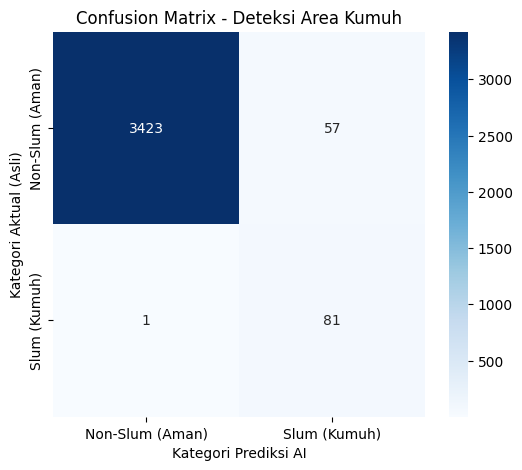

In [6]:
# Load model terbaik untuk pengujian final
model.load_state_dict(torch.load(MODEL_DIR / "final_slum_classifier.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 1. Tampilkan Classification Report
target_names = ['Non-Slum (Aman)', 'Slum (Kumuh)']
print("\n📝 CLASSIFICATION REPORT SKRIPSI:")
print(classification_report(all_labels, all_preds, target_names=target_names))

# 2. Gambar Grafik Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - Deteksi Area Kumuh")
plt.ylabel("Kategori Aktual (Asli)")
plt.xlabel("Kategori Prediksi AI")
plt.show()